# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('sample_data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [ ]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

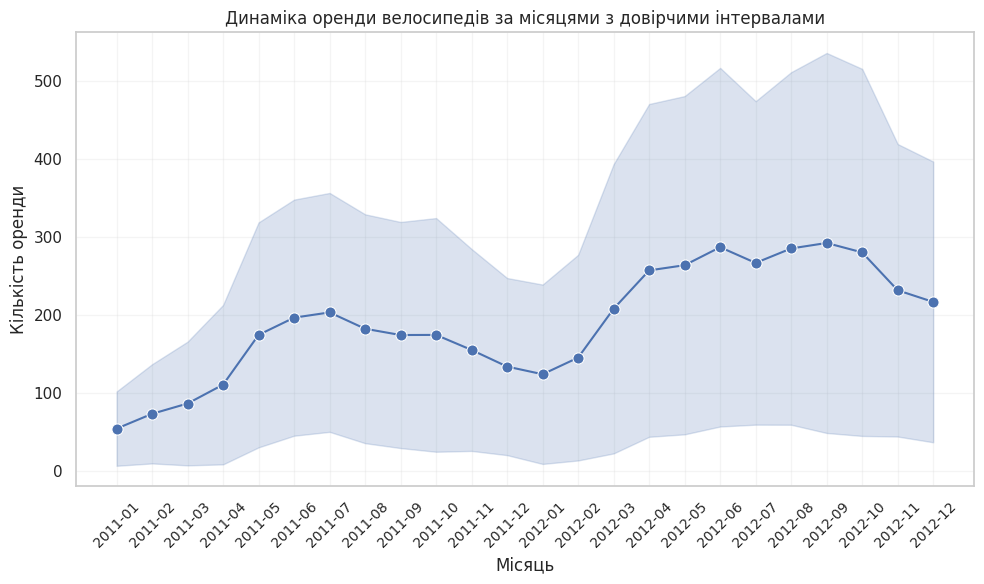

In [18]:
plt.figure(figsize=(10,6))
ax = sns.lineplot(df, x='month_year', y='count', errorbar='sd', marker='o',
                  markersize=8)
plt.title('Динаміка оренди велосипедів за місяцями з довірчими інтервалами')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренди')
plt.xticks(rotation=45, size=10)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


**Відповідь:**
Найбільшу невизначеність в даних ми спостерігаємо у червні, серпні, вересні та жовтні 2012р.
Загалом тренд на збільшення невизначеності ми спостерігаємо з березня 2012р.




## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

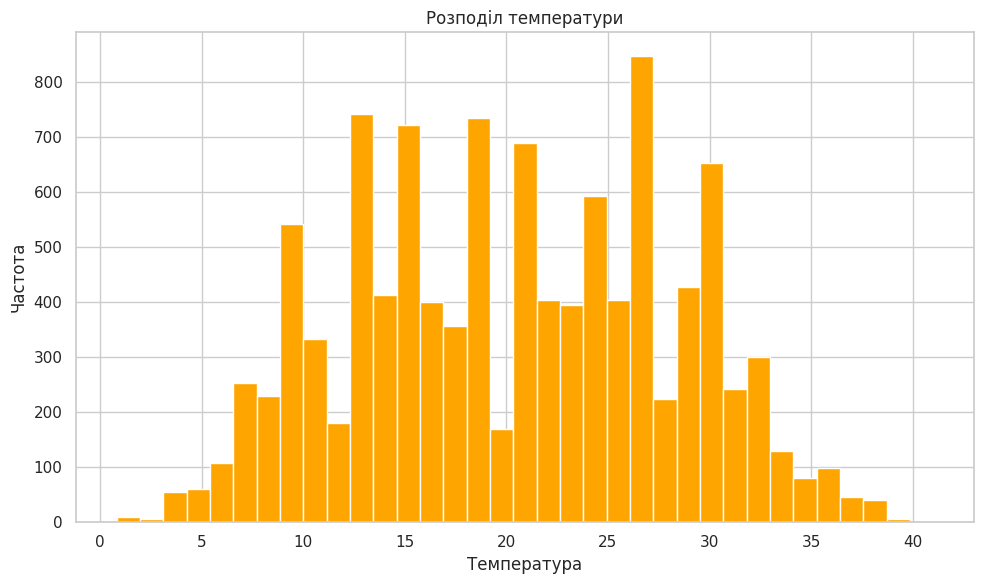

In [ ]:
df['temp'].plot.hist(bins=35,
                     title='Розподіл температури',
                     xlabel='Температура',
                     ylabel='Частота',
                     color='orange',
                     figsize=(10,6))

plt.tight_layout()
plt.show()

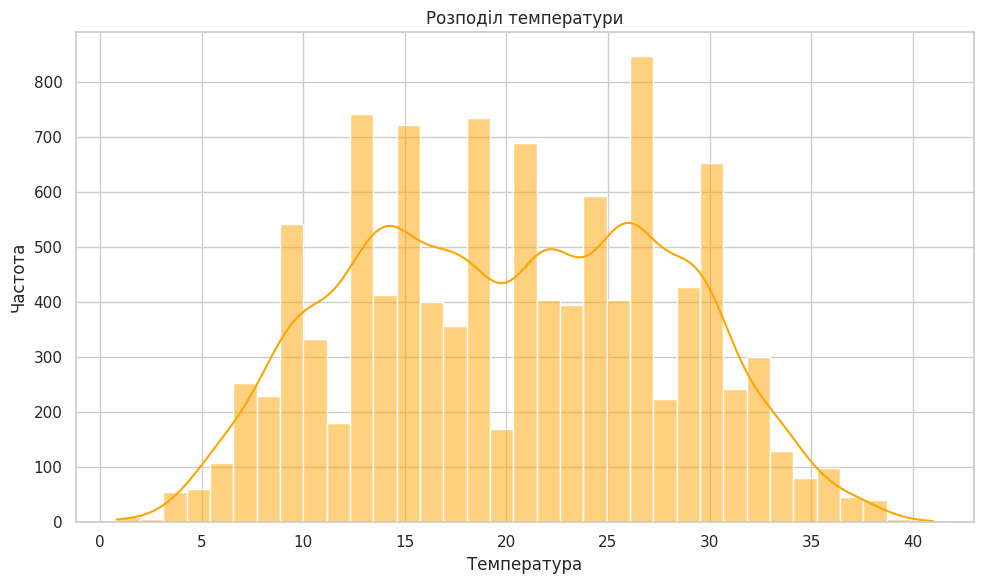

In [ ]:
plt.figure(figsize=(10,6))
ax = sns.histplot(data=df, x='temp', bins=35, color='orange', kde=True)
plt.title('Розподіл температури')
plt.xlabel('Температура')
plt.ylabel('Частота')
ax.grid(alpha=1)

plt.tight_layout()
plt.show()

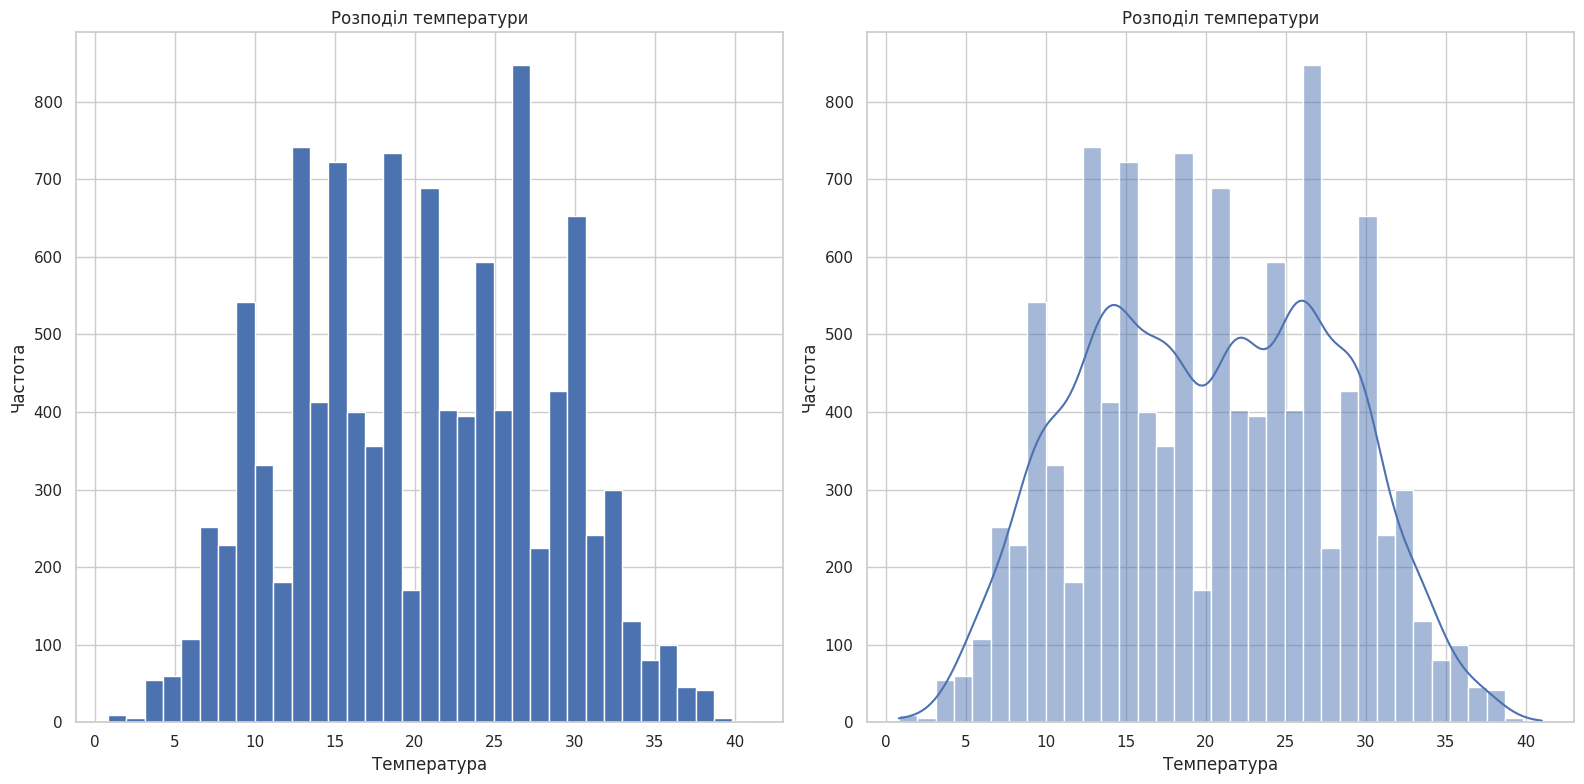

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,8))

df['temp'].plot.hist(bins=35,
                     #color='orange',
                     ax=ax1)
ax1.set_title('Розподіл температури')
ax1.set_xlabel('Температура')
ax1.set_ylabel('Частота')
#ax1.grid(True, alpha=0.5)

sns.histplot(data=df, x='temp', bins=35, kde=True, ax=ax2) #color='orange'
ax2.set_title('Розподіл температури')
ax2.set_xlabel('Температура')
ax2.set_ylabel('Частота')
#ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()



**Відповідь:**
1.**Pandas** за замовчуванням малює більш насичені,непрозорі стовпчики.

**Seaborn** використовує світліші відтінки та робить стовпчики напівпрозорими.



---


2.Додаткова лінія на графіку в Seaborn - це **KDE (Kernel Density Estimation)**.
Вона показує загальну форму тренду даних, згладжує різкі стрибки між окремими стовпчиками гістограми, допомагаючи побачити піки та спади у формі плавної хвилі.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

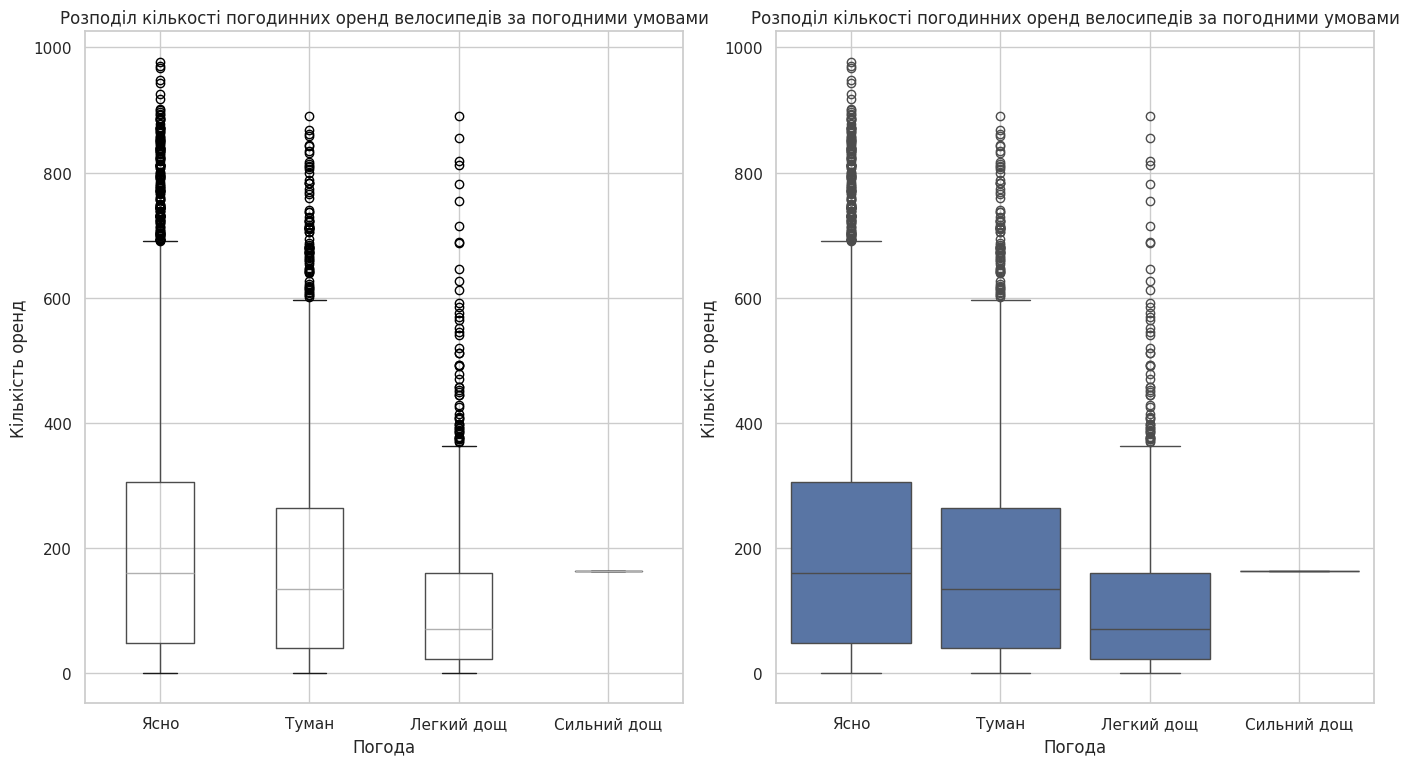

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,8))

ax = df.boxplot(column='count', by='weather', ax=ax1)
ax1.set_title('Розподіл кількості погодинних оренд велосипедів за погодними умовами')
ax1.set_xlabel('Погода')
ax1.set_ylabel('Кількість оренд')
ax1.set_xticklabels(['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'])

sns.boxplot(data=df, x='weather', y='count')
ax2.set_title('Розподіл кількості погодинних оренд велосипедів за погодними умовами')
ax2.set_xlabel('Погода')
ax2.set_ylabel('Кількість оренд')
ax2.set_xticks(range(len(['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'])))
ax2.set_xticklabels(['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'])
ax2.grid(True)

plt.suptitle('')
plt.tight_layout()
plt.show()

**Відповідь:**
*Seaborn* за замовчуванням робить бокс-плот замальованим на відміну від Pandas, останній малює контур без заливки. Бокси в *Seaborn* ширші і візуально, викиди показані приглушеним сірим кольором, тоді як у Pandas вони чіткі й чорні.

На мою думку, *Seaborn* виглядає більш сучасно, а *Pandas* - більш просто і "практично", близький до matplotlib.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


In [ ]:
correlation = df[['count', 'temp', 'atemp', 'humidity', 'windspeed']].corr()
correlation

,count,temp,atemp,humidity,windspeed
count,1.000000,0.394454,0.389784,-0.317371,0.101369
temp,0.394454,1.000000,0.984948,-0.064949,-0.017852
atemp,0.389784,0.984948,1.000000,-0.043536,-0.057473
humidity,-0.317371,-0.064949,-0.043536,1.000000,-0.318607
windspeed,0.101369,-0.017852,-0.057473,-0.318607,1.000000


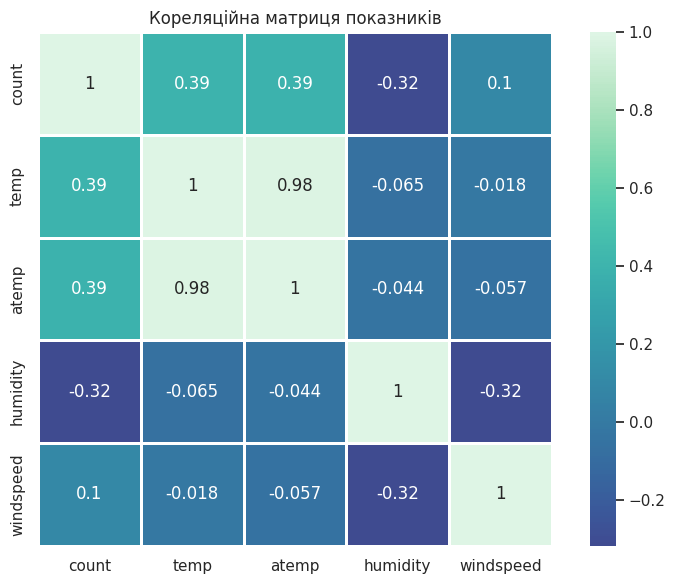

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(correlation, annot=True, cmap='mako', center=0,
            square=True, linewidths=1
            )

plt.title('Кореляційна матриця показників')
plt.tight_layout()
plt.show()

**Відповідь:**
1.Із загальною кількістю оренди найсильніше корелюють температура і відчуття температури(0.39)

2.Кореляція між temp&atemp становить 0.98 - це найбільша позитивна кореляція, бо різниця між фактичною температурою і тим, як вона відчувається незначна.

3.Негативну кореляцію мають наступні змінні:
*   кількість оренд і вологість(-0.32)
*   швидкість вітру і вологість(-0.32)
*   температура і вологість(-0.065)
*   температура і швидкість вітру(-0.018)
*   відчуття температури і вологість(-0.044)
*   відчуття температури і швидкість вітру(-0.0057)





## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


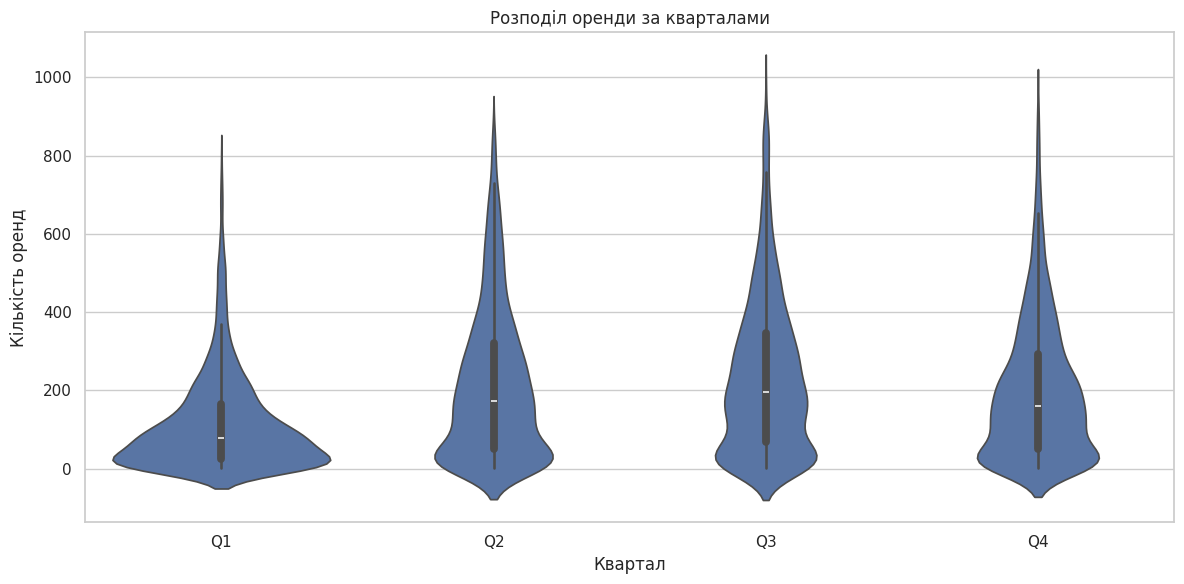

In [ ]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='season', y='count')
plt.xticks([0, 1, 2, 3], ['Q1', 'Q2', 'Q3', 'Q4'])
plt.title('Розподіл оренди за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Кількість оренд')
plt.tight_layout()
plt.show()

**Відповідь:**
1.Товщина violin plot показує частоту значень у даній точці шкали Y.
Чим ширше фігура, тим більше спостережень має саме таке значення.

2. Найбільша варіабельність оренди в Q3 - це найвища і найширша фігура.

3. У violin ми можемо побачити розподіл окрім основних параметрів box plot.


## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

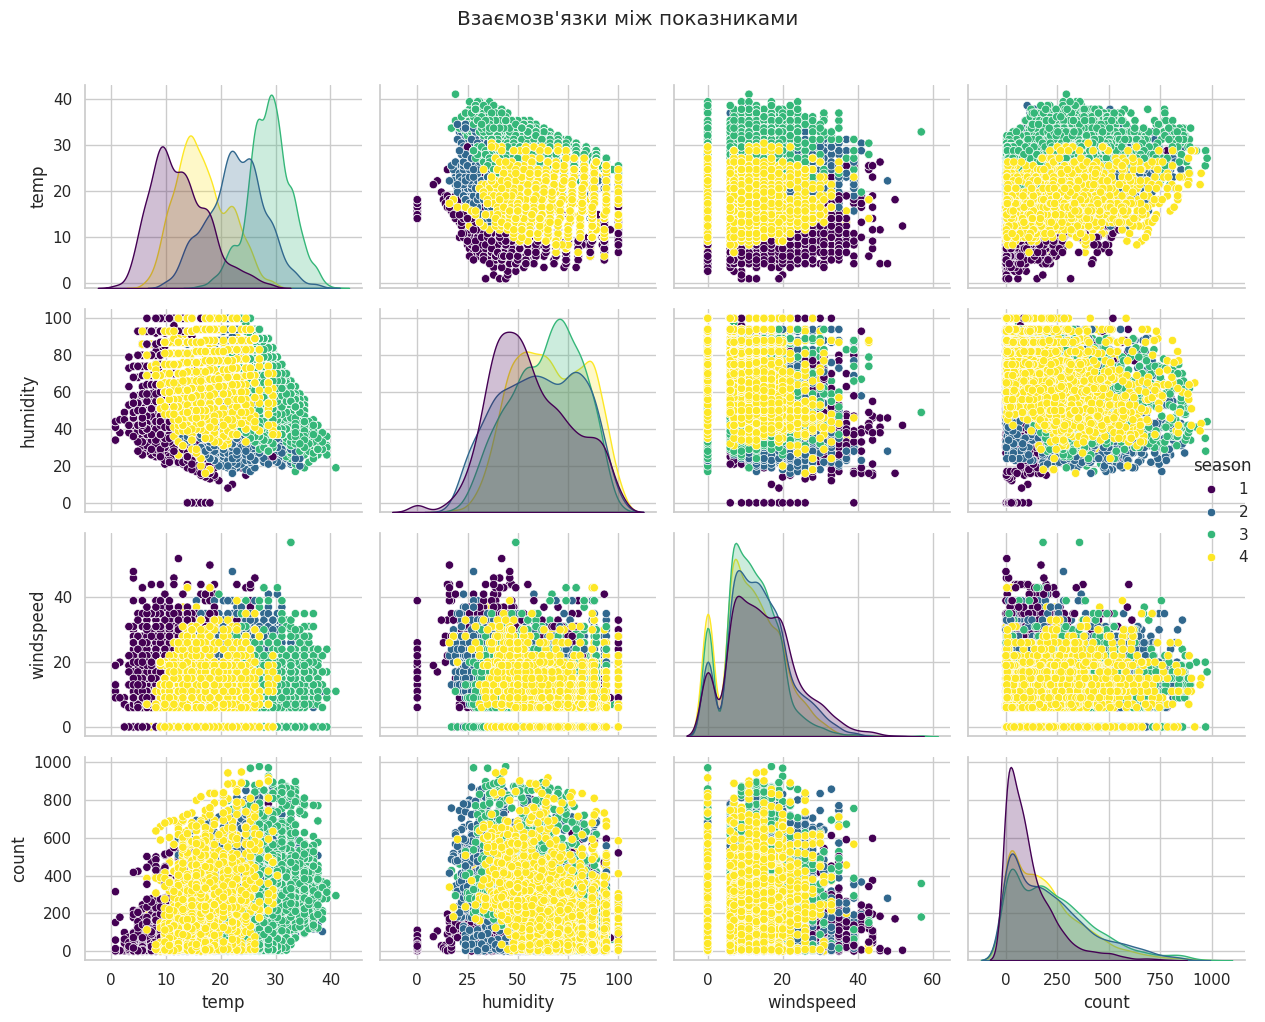

In [ ]:
mini_set=df[['temp', 'humidity', 'windspeed', 'count', 'season']]

sns.pairplot(mini_set, hue='season', height=2.5, aspect=1.2, palette='viridis') #hue — це параметр, який каже seaborn "розфарбуй точки за значеннями цієї колонки"
plt.suptitle("Взаємозв'язки між показниками", y=1.02)
plt.tight_layout()
plt.show();



**Відповідь:**
1.Найсильніший лінійний зв'язок спостерігається між temp і count, чим вища температура, тим більша кількість оренд. Це підтверджує коеф.кореляції 0.39.

2.Характеристика count найбільше відрізняється між кварталами, це видно на діагональних KDE-графіках. Фіолетова гірка(1 квартал) зміщена вліво і є навищою, 3 і 4 більше змішені вправо.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

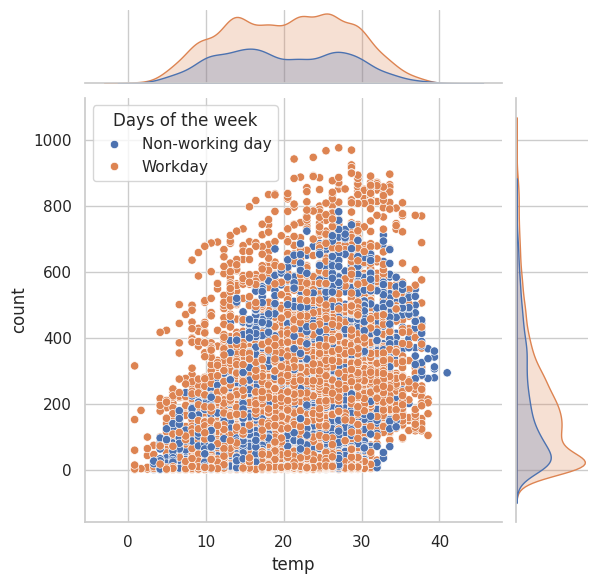

In [43]:
k = sns.jointplot(data=df, x="temp", y="count", hue="workingday")

handles = k.ax_joint.legend_.legend_handles #дістаємо оригінальні кольорові маркери з уже створеної легенди

k.ax_joint.legend(
    handles=handles,
    labels = ['Non-working day', 'Workday'],
    title = 'Days of the week',
    loc='upper left'
    )

plt.show()

In [42]:
df.groupby('workingday')['count'].mean().round(0)

,count
workingday,
0,189.0
1,193.0


**Відповідь:**
1.Графіки по краях показують розподіли по категоріях, які зазначені у "hue" для  змінних x та y.

2.Середня кількість оренд у робочі дні (193) трохи вища, ніж у вихідні (189), хоча різниця досить незначна (~2.4%).
